Skipping field hora_ini_LJ_es: unsupported OGR type: 10
Skipping field hora_fin_LJ_es: unsupported OGR type: 10
Skipping field hora_ini_LJ_ra: unsupported OGR type: 10
Skipping field hora_fin_LJ_ra: unsupported OGR type: 10
Skipping field hora_ini_VS_es: unsupported OGR type: 10
Skipping field hora_fin_VS_es: unsupported OGR type: 10
Skipping field hora_ini_VS_ra: unsupported OGR type: 10
Skipping field hora_fin_VS_ra: unsupported OGR type: 10


Terrazas totales: 6474
Terrazas seleccionadas (tipo_suelo_cod == 1): 5791
Terrazas sin edificio asignado: 287
Edificios con terraza: 4371
Terrazas proyectadas correctamente: 4877 de 5504
Guardado completado.
- Edificios con marca: edificios_con_terraza_og.geojson
- Terrazas proyectadas: terrazas_proyectadas_acera_og.geojson


<Axes: >

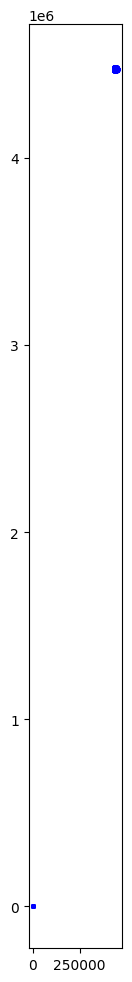

In [2]:
# =========================
# PROYECCIÓN DE TERRAZAS A ACERA
# =========================

import warnings
warnings.filterwarnings("ignore")

import geopandas as gpd
import pandas as pd
import numpy as np

from shapely.geometry import Point, LineString, Polygon, MultiLineString, GeometryCollection
from shapely.ops import unary_union, nearest_points

# -------------------------------------------------
# 1) RUTAS DE ENTRADA / SALIDA
# -------------------------------------------------

RUTA_TERRAZAS = r"C:\Users\khora\Downloads\terrazas.geojson"
RUTA_ACERAS_PLAZA = r"C:\Users\khora\Downloads\acerasPlazas.geojson"
RUTA_ACERAS_CALLE = r"C:\Users\khora\OneDrive - Khora Urban Consulting S.L\Documentos\aceras.geojson"
RUTA_VIALES = r"C:\Users\khora\OneDrive - Khora Urban Consulting S.L\Documentos\viales.geojson"
RUTA_EDIFICIOS = r"C:\Users\khora\OneDrive - Khora Urban Consulting S.L\Documentos\edificiosMadrid.geojson"

SALIDA_EDIFICIOS = "edificios_con_terraza_og.geojson"
SALIDA_TERRAZAS_PROYECTADAS = "terrazas_proyectadas_acera_og.geojson"

# -------------------------------------------------
# 2) PARÁMETROS AJUSTABLES
# -------------------------------------------------
# Campo que indica qué terrazas hay que procesar
CAMPO_TIPO = "tipo_suelo_cod"
VALOR_OBJETIVO = 1

# CRS métrico recomendado
CRS_METRICO = 25830   # ETRS89 / UTM zona 30N, habitual para Madrid

# Ancho de la terraza sobre la línea de fachada (en metros)
ANCHO_TERRAZA_M = 4.0

# Longitud máxima del rayo hacia el exterior para buscar la acera
LONGITUD_RAYO_M = 10.0

# Tolerancia para calcular tangente de fachada
EPS_TANGENTE_M = 0.2

# Distancia de búsqueda inicial para aceras
BUSQUEDA_ACERA_M = 5.0

# Buffer muy pequeño para arreglos geométricos
BUFFER_FIX = 0.001

# -------------------------------------------------
# 3) FUNCIONES AUXILIARES
# -------------------------------------------------
def asegurar_crs_metrico(gdf, crs_objetivo=CRS_METRICO):
    """
    Reproyecta a CRS métrico si hace falta.
    """
    if gdf.crs is None:
        raise ValueError("Una de las capas no tiene CRS definido.")
    if gdf.crs.to_epsg() != crs_objetivo:
        return gdf.to_crs(crs_objetivo)
    return gdf

def vector_unitario(vx, vy):
    norm = np.hypot(vx, vy)
    if norm == 0:
        return np.array([0.0, 0.0])
    return np.array([vx / norm, vy / norm])

def extraer_lineas(geom):
    """
    Devuelve una lista de LineString a partir de una geometría de intersección.
    """
    if geom.is_empty:
        return []
    if geom.geom_type == "LineString":
        return [geom]
    elif geom.geom_type == "MultiLineString":
        return list(geom.geoms)
    elif geom.geom_type == "GeometryCollection":
        out = []
        for g in geom.geoms:
            if g.geom_type == "LineString":
                out.append(g)
            elif g.geom_type == "MultiLineString":
                out.extend(list(g.geoms))
        return out
    else:
        return []

def punto_mas_cercano_en_fachada(point_geom, building_geom):
    """
    Busca el punto de fachada más cercano al punto interior.
    """
    boundary = building_geom.boundary
    _, p_fachada = nearest_points(point_geom, boundary)
    return p_fachada

def tangente_local_en_fachada(building_geom, facade_point, eps=EPS_TANGENTE_M):
    """
    Calcula la tangente local de la fachada en el punto más cercano.
    Usa la frontera del edificio.
    """
    boundary = building_geom.boundary
    
    # Si es MultiLineString, nos quedamos con la línea más cercana al punto de fachada
    if boundary.geom_type == "MultiLineString":
        partes = list(boundary.geoms)
        dists = [g.distance(facade_point) for g in partes]
        line = partes[int(np.argmin(dists))]
    else:
        line = boundary

    d = line.project(facade_point)
    d0 = max(0, d - eps)
    d1 = min(line.length, d + eps)

    p0 = line.interpolate(d0)
    p1 = line.interpolate(d1)

    tx, ty = p1.x - p0.x, p1.y - p0.y
    t = vector_unitario(tx, ty)

    # Si por alguna razón sale cero, intentamos con un eps más grande
    if np.allclose(t, [0.0, 0.0]):
        d0 = max(0, d - eps * 4)
        d1 = min(line.length, d + eps * 4)
        p0 = line.interpolate(d0)
        p1 = line.interpolate(d1)
        tx, ty = p1.x - p0.x, p1.y - p0.y
        t = vector_unitario(tx, ty)

    return t

def obtener_acera_cercana(aceras_gdf, punto, radio=BUSQUEDA_ACERA_M):
    """
    Busca la acera más cercana usando primero un bbox local.
    Si no encuentra, cae a cálculo global.
    """
    sidx = aceras_gdf.sindex
    bbox = punto.buffer(radio).bounds
    idx = list(sidx.intersection(bbox))

    if len(idx) == 0:
        # Fallback global
        d = aceras_gdf.geometry.distance(punto)
        if d.isna().all():
            return None, None
        i = d.idxmin()
        return i, aceras_gdf.loc[i]

    subset = aceras_gdf.iloc[idx].copy()
    subset["__dist"] = subset.geometry.distance(punto)
    i = subset["__dist"].idxmin()
    return i, aceras_gdf.loc[i]

def construir_rectangulo_desde_fachada(facade_point, far_point, tangente, ancho):
    """
    Construye un rectángulo definido por:
    - lado cercano en fachada
    - lado lejano en la acera
    - orientado según la tangente de fachada
    """
    half = ancho / 2.0
    tx, ty = tangente

    # offsets laterales
    ox, oy = tx * half, ty * half

    p1 = (facade_point.x - ox, facade_point.y - oy)
    p2 = (facade_point.x + ox, facade_point.y + oy)
    p3 = (far_point.x + ox, far_point.y + oy)
    p4 = (far_point.x - ox, far_point.y - oy)

    poly = Polygon([p1, p2, p3, p4, p1])
    return poly

def punto_lejano_en_interseccion(ray, acera_geom, facade_point, dir_out):
    """
    Intersecta el rayo con la acera y obtiene el punto más alejado
    en el sentido de salida desde la fachada.
    Soporta coordenadas 2D y 3D.
    """
    inter = ray.intersection(acera_geom)
    if inter.is_empty:
        return None

    segmentos = extraer_lineas(inter)
    if len(segmentos) == 0:
        return None

    coords = []
    for seg in segmentos:
        coords.extend(list(seg.coords))

    if len(coords) == 0:
        return None

    fx, fy = facade_point.x, facade_point.y
    dir_out = np.array(dir_out, dtype=float)

    mejor_p = None
    mejor_val = -np.inf

    for c in coords:
        x, y = c[:2]   # <- aquí está la clave: ignorar Z si existe
        v = np.array([x - fx, y - fy], dtype=float)
        proj = np.dot(v, dir_out)
        if proj > mejor_val:
            mejor_val = proj
            mejor_p = Point(x, y)

    if mejor_p is None or mejor_val <= 0:
        return None

    return mejor_p

def proyectar_terraza_a_acera(point_geom, building_geom, aceras_gdf,
                              ancho_terraza=ANCHO_TERRAZA_M,
                              longitud_rayo=LONGITUD_RAYO_M):
    """
    Para un punto dentro de edificio:
    1) calcula fachada más cercana
    2) obtiene dirección interior->fachada->exterior
    3) busca acera cercana
    4) intersecta un rayo con la acera
    5) crea un polígono rectangular
    """
    if point_geom is None or point_geom.is_empty:
        return None, None, None

    if building_geom is None or building_geom.is_empty:
        return None, None, None

    # 1) Punto de fachada más cercano
    facade_point = punto_mas_cercano_en_fachada(point_geom, building_geom)

    # 2) Dirección de salida: desde el punto interior hacia la fachada y más allá
    dx = facade_point.x - point_geom.x
    dy = facade_point.y - point_geom.y
    dir_out = vector_unitario(dx, dy)

    if np.allclose(dir_out, [0.0, 0.0]):
        return None, facade_point, None

    # 3) Buscar acera cercana a la fachada
    _, acera_row = obtener_acera_cercana(aceras_gdf, facade_point, radio=BUSQUEDA_ACERA_M)
    if acera_row is None:
        return None, facade_point, None

    acera_geom = acera_row.geometry

    # 4) Crear rayo hacia el exterior
    far_ray_point = Point(
        facade_point.x + dir_out[0] * longitud_rayo,
        facade_point.y + dir_out[1] * longitud_rayo
    )
    ray = LineString([facade_point, far_ray_point])

    # Si el rayo no toca la acera, intentamos con la acera más cercana global igualmente
    far_point = punto_lejano_en_interseccion(ray, acera_geom, facade_point, dir_out)

    if far_point is None:
        return None, facade_point, acera_geom

    # 5) Tangente local de fachada para dar ancho al rectángulo
    tangente = tangente_local_en_fachada(building_geom, facade_point, eps=EPS_TANGENTE_M)

    if np.allclose(tangente, [0.0, 0.0]):
        return None, facade_point, acera_geom

    terraza_poly = construir_rectangulo_desde_fachada(
        facade_point=facade_point,
        far_point=far_point,
        tangente=tangente,
        ancho=ancho_terraza
    )

    # Recortar estrictamente a la acera para que no salga fuera
    terraza_poly = terraza_poly.intersection(acera_geom)

    if terraza_poly.is_empty:
        return None, facade_point, acera_geom

    # Arreglo geométrico por si hiciera falta
    terraza_poly = terraza_poly.buffer(0)

    if terraza_poly.is_empty:
        return None, facade_point, acera_geom

    return terraza_poly, facade_point, acera_geom

# -------------------------------------------------
# 4) CARGA DE DATOS
# -------------------------------------------------
terrazas = gpd.read_file(RUTA_TERRAZAS)
aceras_plaza = gpd.read_file(RUTA_ACERAS_PLAZA)
aceras_calle = gpd.read_file(RUTA_ACERAS_CALLE)
viales = gpd.read_file(RUTA_VIALES)
edificios = gpd.read_file(RUTA_EDIFICIOS)

# -------------------------------------------------
# 5) REPROYECCIÓN A CRS MÉTRICO
# -------------------------------------------------
terrazas = asegurar_crs_metrico(terrazas)
aceras_plaza = asegurar_crs_metrico(aceras_plaza)
aceras_calle = asegurar_crs_metrico(aceras_calle)
viales = asegurar_crs_metrico(viales)
edificios = asegurar_crs_metrico(edificios)

# -------------------------------------------------
# 6) LIMPIEZA GEOMÉTRICA BÁSICA
# -------------------------------------------------
edificios["geometry"] = edificios.geometry.buffer(0)
aceras_plaza["geometry"] = aceras_plaza.geometry.buffer(0)
aceras_calle["geometry"] = aceras_calle.geometry.buffer(0)
viales["geometry"] = viales.geometry.buffer(0)

terrazas = terrazas[~terrazas.geometry.is_empty & terrazas.geometry.notna()].copy()
edificios = edificios[~edificios.geometry.is_empty & edificios.geometry.notna()].copy()
aceras_plaza = aceras_plaza[~aceras_plaza.geometry.is_empty & aceras_plaza.geometry.notna()].copy()
aceras_calle = aceras_calle[~aceras_calle.geometry.is_empty & aceras_calle.geometry.notna()].copy()

# -------------------------------------------------
# 7) FILTRAR TERRAZAS OBJETIVO
# -------------------------------------------------
if CAMPO_TIPO not in terrazas.columns:
    raise ValueError(f"El campo '{CAMPO_TIPO}' no existe en la capa de terrazas.")

terrazas_sel = terrazas[terrazas[CAMPO_TIPO] == VALOR_OBJETIVO].copy()

print(f"Terrazas totales: {len(terrazas)}")
print(f"Terrazas seleccionadas ({CAMPO_TIPO} == {VALOR_OBJETIVO}): {len(terrazas_sel)}")

# -------------------------------------------------
# 8) UNIR LAS ACERAS EN UNA SOLA CAPA
# -------------------------------------------------
aceras = pd.concat(
    [
        aceras_plaza.assign(tipo_acera="plaza"),
        aceras_calle.assign(tipo_acera="calle")
    ],
    ignore_index=True
)
aceras = gpd.GeoDataFrame(aceras, geometry="geometry", crs=aceras_plaza.crs)

# -------------------------------------------------
# 9) ASIGNAR CADA TERRAZA A SU EDIFICIO
# -------------------------------------------------
# Guardamos índice original de edificios
edificios = edificios.reset_index(drop=True).copy()
edificios["building_id"] = edificios.index.astype(int)

terrazas_sel = terrazas_sel.reset_index(drop=True).copy()
terrazas_sel["terraza_id"] = terrazas_sel.index.astype(int)

# Spatial join: punto dentro de edificio
terrazas_edif = gpd.sjoin(
    terrazas_sel,
    edificios[["building_id", "geometry"]],
    how="left",
    predicate="within"
).drop(columns=["index_right"], errors="ignore")

sin_edificio = terrazas_edif["building_id"].isna().sum()
print(f"Terrazas sin edificio asignado: {sin_edificio}")

# Nos quedamos con las que sí están en edificio
terrazas_edif_ok = terrazas_edif[terrazas_edif["building_id"].notna()].copy()
terrazas_edif_ok["building_id"] = terrazas_edif_ok["building_id"].astype(int)

# -------------------------------------------------
# 10) MARCAR EDIFICIOS CON TERRAZA
# -------------------------------------------------
edificios["tiene_terraza"] = 0

ids_edificios_con_terraza = terrazas_edif_ok["building_id"].unique().tolist()
edificios.loc[edificios["building_id"].isin(ids_edificios_con_terraza), "tiene_terraza"] = 1

print(f"Edificios con terraza: {edificios['tiene_terraza'].sum()}")

# -------------------------------------------------
# 11) PROYECTAR CADA TERRAZA A LA ACERA
# -------------------------------------------------
# Preparamos acceso rápido a edificios por ID
edificios_idx = edificios.set_index("building_id")

registros = []

for i, row in terrazas_edif_ok.iterrows():
    terraza_id = row["terraza_id"]
    building_id = row["building_id"]
    p = row.geometry
    building_geom = edificios_idx.loc[building_id].geometry

    terraza_poly, facade_point, acera_geom = proyectar_terraza_a_acera(
        point_geom=p,
        building_geom=building_geom,
        aceras_gdf=aceras,
        ancho_terraza=ANCHO_TERRAZA_M,
        longitud_rayo=LONGITUD_RAYO_M
    )

    registros.append({
        "terraza_id": terraza_id,
        "building_id": building_id,
        "procesada": int(terraza_poly is not None and not terraza_poly.is_empty),
        "geometry": terraza_poly,
        "punto_original": p,
        "punto_fachada": facade_point
    })

terr_proj = gpd.GeoDataFrame(registros, geometry="geometry", crs=terrazas.crs)

print(f"Terrazas proyectadas correctamente: {terr_proj['procesada'].sum()} de {len(terr_proj)}")

# -------------------------------------------------
# 12) QUEDARSE SOLO CON POLÍGONOS VÁLIDOS
# -------------------------------------------------
terr_proj_ok = terr_proj[
    terr_proj["geometry"].notna() &
    ~terr_proj.geometry.is_empty &
    (terr_proj["procesada"] == 1)
].copy()

# Arreglos por si aparece MultiPolygon raro o geometrías inválidas
terr_proj_ok["geometry"] = terr_proj_ok.geometry.buffer(0)
terr_proj_ok = terr_proj_ok[
    terr_proj_ok.geometry.notna() &
    ~terr_proj_ok.geometry.is_empty
].copy()

# -------------------------------------------------
# 13) GUARDAR RESULTADOS
# -------------------------------------------------
edificios.to_file(SALIDA_EDIFICIOS, driver="GeoJSON")
terr_proj_ok.to_file(SALIDA_TERRAZAS_PROYECTADAS, driver="GeoJSON")

print("Guardado completado.")
print(f"- Edificios con marca: {SALIDA_EDIFICIOS}")
print(f"- Terrazas proyectadas: {SALIDA_TERRAZAS_PROYECTADAS}")

# -------------------------------------------------
# 14) VISTA RÁPIDA OPCIONAL
# -------------------------------------------------
ax = edificios[edificios["tiene_terraza"] == 1].plot(figsize=(12, 12), alpha=0.3, edgecolor="black")
aceras.plot(ax=ax, color="lightgrey", alpha=0.5)
terr_proj_ok.plot(ax=ax, color="red", alpha=0.7)
terrazas_sel.plot(ax=ax, color="blue", markersize=5)

In [4]:
# =========================
# EXPANDIR TERRAZAS YA PROYECTADAS + PASAR ATRIBUTOS ORIGINALES
# =========================

import warnings
warnings.filterwarnings("ignore")

import geopandas as gpd
import pandas as pd
import numpy as np

from shapely.geometry import Point, LineString, Polygon, MultiPolygon, GeometryCollection
from shapely.ops import nearest_points, transform

# -------------------------------------------------
# 1) RUTAS
# -------------------------------------------------
RUTA_TERRAZAS_ORIG = r"C:\Users\khora\Downloads\terrazas.geojson"
RUTA_TERRAZAS_BASE = r"C:\Users\khora\terrazas_proyectadas_acera_og.geojson"
RUTA_ACERAS_PLAZA = r"C:\Users\khora\Downloads\acerasPlazas.geojson"
RUTA_ACERAS_CALLE = r"C:\Users\khora\OneDrive - Khora Urban Consulting S.L\Documentos\aceras.geojson"
RUTA_EDIFICIOS = r"C:\Users\khora\OneDrive - Khora Urban Consulting S.L\Documentos\edificiosMadrid.geojson"

SALIDA_TERRAZAS_EXPANDIDAS = r"C:\Users\khora\Downloads\terrazas_expandidas_con_atributos.geojson"

# -------------------------------------------------
# 2) PARÁMETROS
# -------------------------------------------------
CAMPO_TIPO = "tipo_suelo_cod"
VALOR_OBJETIVO = 1
CRS_METRICO = 25830

# si existe superficie oficial y quieres usarla antes que la estimación:
USAR_SUPERFICIE_OFICIAL = True

# coeficientes de estimación por mobiliario
M2_POR_MESA = 1.80
M2_POR_SILLA = 0.35
M2_POR_MESA_AUX = 1.20
M2_POR_MESA_ALTA = 1.40
M2_POR_SOMBRILLA = 0.50

# control geométrico
MARGEN_EDIFICIO_M = 0.05
PASO_EXPANSION_M = 0.30
MAX_ITER_EXPANSION = 35
AREA_MINIMA_M2 = 1.0

# si quieres probar pocas terrazas:
N_TEST = 15     # por ejemplo 50, o None para todas

# -------------------------------------------------
# 3) FUNCIONES AUXILIARES
# -------------------------------------------------
def asegurar_crs_metrico(gdf, crs_objetivo=CRS_METRICO):
    if gdf.crs is None:
        raise ValueError("Una de las capas no tiene CRS definido.")
    epsg = gdf.crs.to_epsg()
    if epsg != crs_objetivo:
        return gdf.to_crs(crs_objetivo)
    return gdf

def force_2d_geometry(geom):
    if geom is None or geom.is_empty:
        return geom

    def _to_2d(x, y, z=None):
        return (x, y)

    try:
        return transform(_to_2d, geom)
    except Exception:
        return geom

def force_2d_gdf(gdf):
    gdf = gdf.copy()
    gdf["geometry"] = gdf.geometry.apply(force_2d_geometry)
    return gdf

def limpiar_geometrias(gdf):
    gdf = gdf.copy()

    def _fix(g):
        if g is None or g.is_empty:
            return g
        if g.geom_type in ("Polygon", "MultiPolygon"):
            return g.buffer(0)
        return g

    gdf["geometry"] = gdf.geometry.apply(_fix)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    return gdf

def valor_numerico_seguro(v, default=0.0):
    try:
        if pd.isna(v):
            return default
        return float(v)
    except Exception:
        return default

def obtener_area_objetivo(row):
    """
    Área objetivo basada SOLO en mobiliario.
    Ajusta coeficientes si quieres.
    """
    mesas = max(
        valor_numerico_seguro(row.get("mesas_es", 0)),
        valor_numerico_seguro(row.get("mesas_ra", 0))
    )
    sillas = max(
        valor_numerico_seguro(row.get("sillas_es", 0)),
        valor_numerico_seguro(row.get("sillas_ra", 0))
    )
    mesas_aux = max(
        valor_numerico_seguro(row.get("mesas_aux_es", 0)),
        valor_numerico_seguro(row.get("mesas_aux_ra", 0))
    )
    mesas_altas = max(
        valor_numerico_seguro(row.get("mesas_altas_estacional", 0)),
        valor_numerico_seguro(row.get("mesas_altas_anual", 0))
    )
    sombrillas = max(
        valor_numerico_seguro(row.get("sombrillas_es", 0)),
        valor_numerico_seguro(row.get("sombrillas_ra", 0))
    )

    area_estimada = (
        mesas * 1.80 +
        sillas * 0.35 +
        mesas_aux * 1.20 +
        mesas_altas * 1.40 +
        sombrillas * 0.50
    )

    return max(area_estimada, 4.0)

    

def extraer_poligonos(geom):
    if geom is None or geom.is_empty:
        return []
    if geom.geom_type == "Polygon":
        return [geom]
    if geom.geom_type == "MultiPolygon":
        return [g for g in geom.geoms if g is not None and not g.is_empty]
    if geom.geom_type == "GeometryCollection":
        out = []
        for g in geom.geoms:
            out.extend(extraer_poligonos(g))
        return out
    return []

def quedarse_parte_principal(geom, ref_point=None):
    polys = extraer_poligonos(geom)
    if not polys:
        return None

    if ref_point is None:
        return max(polys, key=lambda g: g.area)

    # primero intentamos la más cercana al punto de referencia
    polys_sorted = sorted(polys, key=lambda g: g.distance(ref_point))
    return polys_sorted[0]
    

def segmentos_exterior(poly):
    polys = extraer_poligonos(poly)
    segs = []

    for p in polys:
        coords = list(p.exterior.coords)
        for i in range(len(coords) - 1):
            p1 = coords[i][:2]
            p2 = coords[i + 1][:2]
            seg = LineString([p1, p2])
            if seg.length > 0:
                segs.append(seg)

    return segs



def obtener_segmento_fachada_desde_base(poly_base, building_geom):
    if poly_base is None or poly_base.is_empty:
        return None

    poly_base = quedarse_parte_principal(poly_base, ref_point=building_geom.centroid)
    if poly_base is None or poly_base.is_empty:
        return None

    segs = segmentos_exterior(poly_base)
    if not segs:
        return None

    return min(segs, key=lambda s: s.distance(building_geom))


    
def vector_unitario(vx, vy):
    norm = np.hypot(vx, vy)
    if norm == 0:
        return np.array([0.0, 0.0])
    return np.array([vx / norm, vy / norm])


def sistema_local_desde_segmento(seg_fachada, poly_base):
    coords = list(seg_fachada.coords)
    x1, y1 = coords[0][:2]
    x2, y2 = coords[-1][:2]

    tang = vector_unitario(x2 - x1, y2 - y1)

    n1 = np.array([-tang[1], tang[0]])
    n2 = np.array([ tang[1],-tang[0]])

    mid = Point((x1 + x2) / 2.0, (y1 + y2) / 2.0)
    cent = poly_base.centroid

    p1 = Point(mid.x + n1[0], mid.y + n1[1])
    p2 = Point(mid.x + n2[0], mid.y + n2[1])

    # queremos la normal que apunte hacia el interior de la terraza base
    if p1.distance(cent) < p2.distance(cent):
        normal = n1
    else:
        normal = n2

    origen = np.array([mid.x, mid.y], dtype=float)
    return origen, tang, normal, mid

    


def proyectar_coord_local(pt, origen, tang, normal):
    v = np.array([pt[0] - origen[0], pt[1] - origen[1]], dtype=float)
    u = np.dot(v, tang)
    w = np.dot(v, normal)
    return u, w

def reconstruir_rectangulo_desde_uv(u_min, u_max, w_min, w_max, origen, tang, normal):
    def xy(u, w):
        p = origen + tang * u + normal * w
        return (float(p[0]), float(p[1]))

    p1 = xy(u_min, w_min)
    p2 = xy(u_max, w_min)
    p3 = xy(u_max, w_max)
    p4 = xy(u_min, w_max)

    return Polygon([p1, p2, p3, p4, p1])

def bounds_uv_de_poligono(poly, origen, tang, normal):
    poly = quedarse_parte_principal(poly)
    coords = list(poly.exterior.coords[:-1])

    us = []
    ws = []

    for x, y in coords:
        u, w = proyectar_coord_local((x, y), origen, tang, normal)
        us.append(u)
        ws.append(w)

    return min(us), max(us), min(ws), max(ws)

    

def recortar_a_espacio_valido(poly, acera_geom, building_geom):
    if poly is None or poly.is_empty:
        return None

    espacio_valido = acera_geom.difference(building_geom.buffer(MARGEN_EDIFICIO_M))
    if espacio_valido.is_empty:
        return None

    out = poly.intersection(espacio_valido)
    if out.is_empty:
        return None

    out = out.buffer(0)
    if out.is_empty:
        return None

    return out

def expandir_poligono_base(poly_base, building_geom, acera_geom, area_objetivo):
    """
    Expande la terraza SOLO paralela a la fachada/acera.
    Mantiene la profundidad del polígono base y recalcula el ancho
    para alcanzar el área objetivo.
    """
    if poly_base is None or poly_base.is_empty:
        return None, 0.0

    poly_base = poly_base.buffer(0)
    poly_base = quedarse_parte_principal(poly_base, ref_point=building_geom.centroid)

    if poly_base is None or poly_base.is_empty:
        return None, 0.0

    seg_fachada = obtener_segmento_fachada_desde_base(poly_base, building_geom)
    if seg_fachada is None:
        return poly_base, poly_base.area

    origen, tang, normal, mid_fachada = sistema_local_desde_segmento(seg_fachada, poly_base)
    u_min, u_max, w_min, w_max = bounds_uv_de_poligono(poly_base, origen, tang, normal)

    ancho_actual = u_max - u_min
    profundidad_actual = w_max - w_min

    if ancho_actual <= 0 or profundidad_actual <= 0:
        return poly_base, poly_base.area

    # ancho necesario para cumplir el área objetivo
    ancho_objetivo = area_objetivo / profundidad_actual

    # si el área objetivo ya es menor, no reducimos; mantenemos base
    if ancho_objetivo <= ancho_actual:
        return poly_base, poly_base.area

    exceso = ancho_objetivo - ancho_actual
    crecer_cada_lado = exceso / 2.0

    nuevo_u_min = u_min - crecer_cada_lado
    nuevo_u_max = u_max + crecer_cada_lado

    candidato = reconstruir_rectangulo_desde_uv(
        nuevo_u_min, nuevo_u_max, w_min, w_max, origen, tang, normal
    )

    candidato = recortar_a_espacio_valido(candidato, acera_geom, building_geom)
    if candidato is None or candidato.is_empty:
        return poly_base, poly_base.area

    candidato = quedarse_parte_principal(candidato, ref_point=mid_fachada)
    if candidato is None or candidato.is_empty:
        return poly_base, poly_base.area

    return candidato, candidato.area

    

def convertir_campos_problematicos_a_texto(gdf):
    """
    Evita problemas al escribir GeoJSON con algunos tipos raros.
    """
    gdf = gdf.copy()
    for col in gdf.columns:
        if col == "geometry":
            continue
        # convertimos solo objetos mixtos problemáticos
        if str(gdf[col].dtype) == "object":
            gdf[col] = gdf[col].apply(lambda x: None if pd.isna(x) else x)
    return gdf

# -------------------------------------------------
# 4) CARGA DE DATOS
# -------------------------------------------------
terrazas_orig = gpd.read_file(RUTA_TERRAZAS_ORIG)
terrazas_base = gpd.read_file(RUTA_TERRAZAS_BASE)
aceras_plaza = gpd.read_file(RUTA_ACERAS_PLAZA)
aceras_calle = gpd.read_file(RUTA_ACERAS_CALLE)
edificios = gpd.read_file(RUTA_EDIFICIOS)

# -------------------------------------------------
# 5) NORMALIZAR
# -------------------------------------------------
terrazas_orig = force_2d_gdf(terrazas_orig)
terrazas_base = force_2d_gdf(terrazas_base)
aceras_plaza = force_2d_gdf(aceras_plaza)
aceras_calle = force_2d_gdf(aceras_calle)
edificios = force_2d_gdf(edificios)

terrazas_orig = asegurar_crs_metrico(terrazas_orig)
terrazas_base = asegurar_crs_metrico(terrazas_base)
aceras_plaza = asegurar_crs_metrico(aceras_plaza)
aceras_calle = asegurar_crs_metrico(aceras_calle)
edificios = asegurar_crs_metrico(edificios)

terrazas_orig = limpiar_geometrias(terrazas_orig)
terrazas_base = limpiar_geometrias(terrazas_base)
aceras_plaza = limpiar_geometrias(aceras_plaza)
aceras_calle = limpiar_geometrias(aceras_calle)
edificios = limpiar_geometrias(edificios)

# -------------------------------------------------
# 6) RECONSTRUIR terraza_id EN LA CAPA ORIGINAL
# -------------------------------------------------
if CAMPO_TIPO not in terrazas_orig.columns:
    raise ValueError(f"El campo '{CAMPO_TIPO}' no existe en la capa original de terrazas.")

terrazas_sel = terrazas_orig[terrazas_orig[CAMPO_TIPO] == VALOR_OBJETIVO].copy()
terrazas_sel = terrazas_sel.reset_index(drop=True)
terrazas_sel["terraza_id"] = terrazas_sel.index.astype(int)

# -------------------------------------------------
# 7) ACERAS UNIFICADAS
# -------------------------------------------------
aceras = pd.concat(
    [
        aceras_plaza.assign(tipo_acera="plaza"),
        aceras_calle.assign(tipo_acera="calle")
    ],
    ignore_index=True
)
aceras = gpd.GeoDataFrame(aceras, geometry="geometry", crs=aceras_plaza.crs)
aceras = limpiar_geometrias(aceras)

# -------------------------------------------------
# 8) PREPARAR EDIFICIOS
# -------------------------------------------------
edificios = edificios.reset_index(drop=True).copy()
edificios["building_id"] = edificios.index.astype(int)
edificios_idx = edificios.set_index("building_id")

# -------------------------------------------------
# 9) ENLAZAR POLÍGONOS BASE CON ATRIBUTOS ORIGINALES
# -------------------------------------------------
if "terraza_id" not in terrazas_base.columns:
    raise ValueError("La capa base de polígonos no tiene 'terraza_id'. No se puede hacer el enlace.")

base = terrazas_base.copy()

# nos quedamos con las terrazas base válidas
if "procesada" in base.columns:
    base = base[base["procesada"] == 1].copy()

# join por terraza_id
base_full = base.merge(
    terrazas_sel.drop(columns="geometry"),
    on="terraza_id",
    how="left",
    suffixes=("", "_orig")
)

# si building_id no está, lo recalculamos
if "building_id" not in base_full.columns:
    base_full = gpd.GeoDataFrame(base_full, geometry="geometry", crs=terrazas_base.crs)
    base_full = gpd.sjoin(
        base_full,
        edificios[["building_id", "geometry"]],
        how="left",
        predicate="intersects"
    ).drop(columns=["index_right"], errors="ignore")
else:
    base_full = gpd.GeoDataFrame(base_full, geometry="geometry", crs=terrazas_base.crs)

# filtro test opcional
if N_TEST is not None:
    base_full = base_full.head(N_TEST).copy()
    print(f"Modo test: {len(base_full)} terrazas")

print(f"Polígonos base a expandir: {len(base_full)}")

# -------------------------------------------------
# 10) EXPANSIÓN
# -------------------------------------------------
registros = []

for i, row in base_full.iterrows():
    poly_base = row.geometry

    if poly_base is None or poly_base.is_empty:
        continue

    building_id = row.get("building_id", None)
    if pd.isna(building_id):
        continue

    building_id = int(building_id)
    building_geom = edificios_idx.loc[building_id].geometry

    # acera más cercana al polígono base
    d = aceras.geometry.distance(poly_base.centroid)
    if d.isna().all():
        continue
    acera_geom = aceras.loc[d.idxmin()].geometry

    area_objetivo = obtener_area_objetivo(row)

    poly_expandida, area_final = expandir_poligono_base(
        poly_base=poly_base,
        building_geom=building_geom,
        acera_geom=acera_geom,
        area_objetivo=area_objetivo
    )

    if poly_expandida is None or poly_expandida.is_empty or poly_expandida.area < AREA_MINIMA_M2:
        poly_expandida = poly_base
        area_final = poly_base.area

    registro = row.drop(labels="geometry").to_dict()
    registro.update({
        "area_base": poly_base.area,
        "area_objetivo": area_objetivo,
        "area_final": area_final,
        "ratio_ocupacion": (area_final / area_objetivo) if area_objetivo and area_objetivo > 0 else None,
        "geometry": poly_expandida
    })

    registros.append(registro)

    if (len(registros) % 250) == 0:
        print(f"Procesadas {len(registros)}/{len(base_full)}")

terr_final = gpd.GeoDataFrame(registros, geometry="geometry", crs=base_full.crs)

# -------------------------------------------------
# 11) LIMPIEZA FINAL
# -------------------------------------------------
terr_final = terr_final[
    terr_final.geometry.notna() &
    ~terr_final.geometry.is_empty
].copy()

terr_final["geometry"] = terr_final.geometry.apply(lambda g: g.buffer(0) if g is not None and not g.is_empty else g)
terr_final = terr_final[
    terr_final.geometry.notna() &
    ~terr_final.geometry.is_empty
].copy()

terr_final = convertir_campos_problematicos_a_texto(terr_final)

print(f"Terrazas finales: {len(terr_final)}")

# -------------------------------------------------
# 12) GUARDAR
# -------------------------------------------------
terr_final.to_file(SALIDA_TERRAZAS_EXPANDIDAS, driver="GeoJSON")

print("Guardado completado.")
print(f"Salida: {SALIDA_TERRAZAS_EXPANDIDAS}")



Skipping field hora_ini_LJ_es: unsupported OGR type: 10
Skipping field hora_fin_LJ_es: unsupported OGR type: 10
Skipping field hora_ini_LJ_ra: unsupported OGR type: 10
Skipping field hora_fin_LJ_ra: unsupported OGR type: 10
Skipping field hora_ini_VS_es: unsupported OGR type: 10
Skipping field hora_fin_VS_es: unsupported OGR type: 10
Skipping field hora_ini_VS_ra: unsupported OGR type: 10
Skipping field hora_fin_VS_ra: unsupported OGR type: 10


Modo test: 15 terrazas
Polígonos base a expandir: 15
Terrazas finales: 15
Guardado completado.
Salida: C:\Users\khora\Downloads\terrazas_expandidas_con_atributos.geojson


In [ ]:
import math
from pathlib import Path

import numpy as np
import laspy
import rasterio
from rasterio.transform import from_origin

# Carpeta con todos los .laz / .las
input_dir = Path(r"D:\Fuenla")

# Salida única
out_tif = input_dir / "MDSFuenlabrada.tif"

resolution = 1.0
nodata_value = -9999.0

# Filtros de Z
z_min_filter = -5
z_max_filter = 150

# Percentiles robustos por archivo
use_percentile_filter = True
p_low = 0.1
p_high = 99.9

# Buscar todos los archivos LiDAR
files = sorted(list(input_dir.glob("*.laz")) + list(input_dir.glob("*.las")))

if not files:
    raise FileNotFoundError(f"No se encontraron .laz o .las en {input_dir}")

print(f"Archivos encontrados: {len(files)}")
for f in files[:10]:
    print(" -", f.name)
if len(files) > 10:
    print(" ...")

# ============================================================
# 1) Primera pasada: extensión global real
# ============================================================
global_xmin = np.inf
global_ymin = np.inf
global_xmax = -np.inf
global_ymax = -np.inf
crs = None

for i, f in enumerate(files, 1):
    las = laspy.read(f)

    x = np.asarray(las.x, dtype=np.float64)
    y = np.asarray(las.y, dtype=np.float64)

    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()

    global_xmin = min(global_xmin, xmin)
    global_ymin = min(global_ymin, ymin)
    global_xmax = max(global_xmax, xmax)
    global_ymax = max(global_ymax, ymax)

    if crs is None:
        try:
            crs = las.header.parse_crs()
        except Exception:
            crs = None

    print(f"[{i}/{len(files)}] {f.name}  X=({xmin:.2f}, {xmax:.2f})  Y=({ymin:.2f}, {ymax:.2f})")

# ============================================================
# 2) Alinear la rejilla global a la resolución
#    Esto evita desplazamientos de píxel
# ============================================================
origin_x = math.floor(global_xmin / resolution) * resolution
origin_y = math.ceil(global_ymax / resolution) * resolution

end_x = math.ceil(global_xmax / resolution) * resolution
end_y = math.floor(global_ymin / resolution) * resolution

width = int(round((end_x - origin_x) / resolution))
height = int(round((origin_y - end_y) / resolution))

print("\nExtensión global alineada:")
print(f"X: {origin_x:.3f} .. {end_x:.3f}")
print(f"Y: {end_y:.3f} .. {origin_y:.3f}")
print(f"Raster final: {width} x {height} píxeles")
print(f"Resolución: {resolution} m")
print("CRS:", crs)

# ============================================================
# 3) Crear raster global
# ============================================================
dsm = np.full((height, width), -np.inf, dtype=np.float32)

for i, f in enumerate(files, 1):
    print(f"\nProcesando [{i}/{len(files)}]: {f.name}")

    las = laspy.read(f)

    x = np.asarray(las.x, dtype=np.float64)
    y = np.asarray(las.y, dtype=np.float64)
    z = np.asarray(las.z, dtype=np.float32)

    print(f"  Puntos: {len(x):,}")
    print(f"  Z original: {z.min():.3f} .. {z.max():.3f}")

    # Filtro básico
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

    # Quitar ruido clasificado si existe
    if hasattr(las, "classification"):
        cls = np.asarray(las.classification)
        valid &= (cls != 7)

    # Filtro robusto por percentiles dentro del propio archivo
    if use_percentile_filter:
        z_valid = z[valid]
        if len(z_valid) > 0:
            zl, zh = np.percentile(z_valid, [p_low, p_high])
            valid &= (z >= zl) & (z <= zh)
            print(f"  Percentiles usados: {zl:.3f} .. {zh:.3f}")

    x = x[valid]
    y = y[valid]
    z = z[valid]

    print(f"  Puntos válidos: {len(x):,}")
    if len(x) == 0:
        print("  AVISO: archivo sin puntos válidos tras filtrar, se omite.")
        continue

    print(f"  Z filtrada: {z.min():.3f} .. {z.max():.3f}")

    # OJO: usar SIEMPRE la rejilla global alineada
    cols = np.floor((x - origin_x) / resolution).astype(np.int64)
    rows = np.floor((origin_y - y) / resolution).astype(np.int64)

    inside = (cols >= 0) & (cols < width) & (rows >= 0) & (rows < height)

    cols = cols[inside]
    rows = rows[inside]
    zv = np.asarray(z[inside], dtype=np.float32)

    flat_idx = rows * width + cols
    dsm_flat = dsm.ravel()

    np.maximum.at(dsm_flat, flat_idx, zv)

print("\nTodos los archivos procesados.")

# ============================================================
# 4) Convertir vacíos a nodata
# ============================================================
dsm[dsm == -np.inf] = nodata_value

valid_dsm = dsm != nodata_value
print("DSM global generado")
print("Min:", float(np.min(dsm[valid_dsm])))
print("Max:", float(np.max(dsm[valid_dsm])))
print("Nodata cells:", int(np.sum(~valid_dsm)))

# ============================================================
# 5) Guardar GeoTIFF
# ============================================================
transform = from_origin(origin_x, origin_y, resolution, resolution)

with rasterio.open(
    out_tif,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs=crs,
    transform=transform,
    nodata=nodata_value,
    compress="lzw",
    tiled=True,
    BIGTIFF="IF_SAFER"
) as dst:
    dst.write(dsm, 1)

print("Guardado en:", out_tif)